In [1]:
import numpy as np
from dataclasses import dataclass
from multiprocessing import Pool, cpu_count
import plotly.graph_objects as go
from ipywidgets import FloatSlider, VBox, HBox, Checkbox, Layout,Button
from ipywidgets import IntSlider, interactive_output, Text, FloatText, IntText
from scipy import optimize
import json
import os
import time
import matplotlib.pyplot as plt

In [2]:
#상수 값 할당
c = 1 # 빛의 속도
k = 1 # 쿨롱 상수
epsilon_0=1  # 진공 유전율
#c =2.998e8  # m/s
#k = 8.9875e9  # N·m²/C²
#epsilon_0=8.854e-12  # F/m
RANGE_LIMIT = 2 # 시각화 영역 한계값(-RANGE_LIMIT, RANGE_LIMIT)

In [3]:
def Lorentzmatrix(velocity):
    v=np.array(velocity)
    if np.sum(v**2) == 0:
        return np.identity(4)
    beta_vec=v/c
    beta_sq=np.sum((v/c)**2)
    gamma=1/np.sqrt(1-beta_sq)
    L=np.zeros((4,4))
    L[0,0]=gamma
    L[0,1:4]=-gamma*beta_vec
    L[1:4,0]=-gamma*beta_vec

    outer_product=np.outer(beta_vec,beta_vec)
    space=np.identity(3)+(gamma-1)*outer_product/beta_sq
    L[1:4,1:4]=space
    return L

In [4]:
@dataclass
class PointCharge:
    q: float       # 전하량
    pos: np.ndarray # 위치 벡터 

class ChargeField:
    def __init__(self, shared_charges=None):
        if shared_charges is not None:
            self.charges = shared_charges
        else:
            self.charges = []
            
    def add_charge(self, q, pos):
        self.charges.append(PointCharge(q, np.array(pos)))
          
    def random_charges(self, n, q_range=(-1.0, 1.0), space_range=None):
        """
        n: 생성할 전하 개수
        q_range: (최소 전하량, 최대 전하량)
        space_range: (최소 좌표, 최대 좌표) - 큐브 형태
        """
        if space_range is None:
            space_range=(-RANGE_LIMIT, RANGE_LIMIT)
        for _ in range(n):
            q = np.random.uniform(*q_range)
            pos = np.random.uniform(*space_range, size=3)
            self.add_charge(q, pos)
    
    def clear_charges(self):
        self.charges.clear()
    
    def save_to_json(self,filename="charges.json"):
        data=[]
        for c in self.charges:
            data.append({"q": c.q, "pos": c.pos.tolist()})
            
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
        print(f"Saved {len(self.charges)} charges to '{filename}'")

    def load_from_json(self, filename="charges.json"):
        if not os.path.exists(filename):
            print(f"File '{filename}' not found!")
            return

        with open(filename, 'r') as f:
            data = json.load(f)
            
        self.clear_charges()
        for item in data:
            self.add_charge(item['q'], item['pos'])
            
        print(f"Loaded {len(self.charges)} charges from '{filename}'")

    def undo_charge(self):
        if self.charges: self.charges.pop()

    @staticmethod #병렬화는 self 있으면 못씀
    def _calculate(X, Y, Z, target_charges):
        Ex = np.zeros_like(X)
        Ey = np.zeros_like(Y)
        Ez = np.zeros_like(Z)
        singularity_mask = np.zeros_like(X, dtype=bool)

        for charge in target_charges:
            rx = X - charge.pos[0]
            ry = Y - charge.pos[1]
            rz = Z - charge.pos[2] 
            R_sq = rx**2 + ry**2 + rz**2

            # 특이점(전하 위치) 처리
            too_close = R_sq < 1e-10
            singularity_mask |= too_close
            R_sq[too_close] = 1.0
            R_cube = R_sq ** 1.5

            Ex += k*charge.q * rx / R_cube
            Ey += k*charge.q * ry / R_cube
            Ez += k*charge.q * rz / R_cube
            
        # 특이점 nan으로 처리해서 그래프로 그리지 않도록 함.  
        Ex[singularity_mask]=np.nan
        Ey[singularity_mask]=np.nan
        Ez[singularity_mask]=np.nan

        return Ex, Ey, Ez
    
    def calc_static_field(self,X, Y, Z, override_charges=None):
        target_charges = override_charges if override_charges is not None else self.charges
        return ChargeField._calculate(X, Y, Z, target_charges)

    def calc_static_field_parallel(self, X, Y, Z, override_charges=None, num_cores=None):
        target_charges = override_charges if override_charges is not None else self.charges

        if num_cores is None: num_cores=cpu_count()

        chunks_X = np.array_split(X, num_cores)
        chunks_Y = np.array_split(Y, num_cores)
        chunks_Z = np.array_split(Z, num_cores)

        tasks = []
        for i in range(num_cores):
            tasks.append((chunks_X[i], chunks_Y[i], chunks_Z[i], target_charges))
        with Pool(num_cores) as pool:
            results = pool.starmap(ChargeField._calculate, tasks)
            
        # 4. 조립
        Ex = np.concatenate([res[0] for res in results])
        Ey = np.concatenate([res[1] for res in results])
        Ez = np.concatenate([res[2] for res in results])
        
        return Ex.reshape(X.shape), Ey.reshape(Y.shape), Ez.reshape(Z.shape)

In [5]:
class TensorField(ChargeField):
    def _transf_system(self, X,Y,Z, charges, velocity):
        '''
        좌표와 전하를 정지계 기준의 좌표로 변환
        '''
        L=Lorentzmatrix(-np.array(velocity))
        
        #좌표 변환
        T=np.zeros_like(X) #시간 축 벡터 생성
        Coords=np.stack([T, X, Y, Z], axis=0)
        
        Coords_prime=np.einsum('ij,j...->i...',L,Coords)

        X_rest, Y_rest, Z_rest = Coords_prime[1], Coords_prime[2], Coords_prime[3]

        #전하 변환
        transformed_charges = []
        for charge in charges:
            q_vec = np.array([0, charge.pos[0], charge.pos[1], charge.pos[2]])
        
            q_vec_prime = L @ q_vec
            
            p_rest = q_vec_prime[1:4]
            transformed_charges.append(PointCharge(charge.q, p_rest))

        return X_rest, Y_rest, Z_rest, transformed_charges

    def get_transformed_field(self, X, Y, Z, velocity):
        total_workload =X.size * len(self.charges)
        X_rest,Y_rest,Z_rest,charges_rest=self._transf_system(X,Y,Z,self.charges,velocity)
    
        if total_workload < 1_000_000:
            Ex, Ey, Ez = self.calc_static_field_parallel(X_rest, Y_rest, Z_rest, override_charges=charges_rest)
        else:
            Ex, Ey, Ez = self.calc_static_field(X_rest, Y_rest, Z_rest, override_charges=charges_rest)


        L = Lorentzmatrix(velocity)

        F = np.zeros(Ex.shape + (4, 4))

        #E_i=c*F_0i
        F[..., 0, 1] = Ex / c;  F[..., 1, 0] = -Ex / c
        F[..., 0, 2] = Ey / c;  F[..., 2, 0] = -Ey / c
        F[..., 0, 3] = Ez / c;  F[..., 3, 0] = -Ez / c
        
        F_prime=L @ F @ L #L==L^T

        return self.get_prime_fields(F_prime)
    
    def get_prime_fields(self,F):
        #moveaxis: (...,3)->(3,...)
        E_prime=np.moveaxis(F[..., 0, 1:4] * c, -1, 0)
        B_prime=np.array([F[...,2,3],F[...,3,1],F[...,1,2]])
        return E_prime,B_prime #각각 요소를 사용시 *붙여야함

In [6]:
class LWField(ChargeField):
    @staticmethod
    def _get_charge_pos(q_r0,v,a,t):
        return q_r0+v * t + 0.5 * a * t**2 #등가속도 운동으로 가정
    
    @staticmethod
    def _retarded_eq(tr, t,r0,q_r0,v0,a0):
        ''' 
        shoot function
        f(tr)=c*(t-tr)-|r-w(tr)|을 반환(0과의 오차)
        해당 함수의 root가 지연시간 tr
        '''
        w_tr=LWField._get_charge_pos(q_r0,v0,a0,tr)
        r_LW = r0- w_tr
        r_LW_mag = np.linalg.norm(r_LW)
        return c * (t - tr) - r_LW_mag
    
    @staticmethod
    def _solve_tr(r0,q_r0, v0,a0,t=0):
        t_max=t
        t_min=t-10*RANGE_LIMIT/c
        try:
            tr=optimize.brentq(LWField._retarded_eq, t_min, t_max, args=(t,r0,q_r0,v0,a0),xtol=1e-12)
        except ValueError:
            return np.nan
        return tr

    @staticmethod
    def _calculate(flat_X, flat_Y, flat_Z, velocity,charges):
        d=0
        #검증을 위한 속도, 가속도 설정
        v=-np.array(velocity)
        a=np.zeros(3) #검증을 위한 등속도 상황이므로 일단 0으로 둠

        Grid_length = len(flat_X)
       
        E_flat=np.zeros((Grid_length,3))
        B_flat=np.zeros((Grid_length,3))

        for charge in charges:
            for i in range(Grid_length):
                r0=np.array([flat_X[i], flat_Y[i], flat_Z[i]])
                tr=LWField._solve_tr(r0,charge.pos, v, a)
                if np.isnan(tr):
                    d+=1
                    continue

                #field 계산에 필요한 요소 계산
                w_tr=LWField._get_charge_pos(charge.pos,v,a,tr)
                r_LW = r0 - w_tr
                r_LW_mag = np.linalg.norm(r_LW)
                if r_LW_mag < 1e-10: #singular point 처리
                    E_flat[i]=np.nan 
                    B_flat[i]=np.nan
                    continue 
                r_n=r_LW / r_LW_mag
                u=c * (r_LW / r_LW_mag) - v
                v_sq=np.sum(v**2)
                
                E_vec= k*charge.q* r_LW_mag * (((c**2)-v_sq)*u + np.cross(r_LW, np.cross(u, a)))/(np.dot(r_LW,u)**3)
            
                B_vec= np.cross(r_n, E_vec)/c
                E_flat[i]+=E_vec
                B_flat[i]+=B_vec    
        return E_flat, B_flat
    
    def calc_field(self, X, Y, Z, velocity):
        flat_X = X.flatten()
        flat_Y = Y.flatten()
        flat_Z = Z.flatten()
        E_flat,B_flat=self._calculate(flat_X,flat_Y,flat_Z,velocity,self.charges)
        E_prime = E_flat.reshape(X.shape + (3,))
        B_prime = B_flat.reshape(X.shape + (3,))
        
        E_out = np.moveaxis(E_prime, -1, 0)
        B_out = np.moveaxis(B_prime, -1, 0)
        return E_out,B_out
        
    def calc_field_parallel(self, X,Y,Z, velocity, num_cores=None):
        flat_X = X.flatten()
        flat_Y = Y.flatten()
        flat_Z = Z.flatten()
        if num_cores is None: num_cores=cpu_count()
        chunks_X = np.array_split(flat_X, num_cores)
        chunks_Y = np.array_split(flat_Y, num_cores)
        chunks_Z = np.array_split(flat_Z, num_cores)
            
        tasks = [(chunks_X[i], chunks_Y[i], chunks_Z[i], velocity, self.charges) for i in range(num_cores)]
            
        with Pool(num_cores) as pool:
                results = pool.starmap(self._calculate, tasks)
            
        E_flat = np.concatenate([r[0] for r in results])
        B_flat = np.concatenate([r[1] for r in results])
        E_prime = E_flat.reshape(X.shape + (3,))
        B_prime = B_flat.reshape(X.shape + (3,))
        E_out = np.moveaxis(E_prime, -1, 0)
        B_out = np.moveaxis(B_prime, -1, 0)
        return E_out,B_out
        
        

    def get_transformed_field(self, X, Y, Z, velocity):
        total_workload =X.size * len(self.charges)
        if total_workload < 1_000_000:
            E,B=self.calc_field(X, Y, Z,velocity)
        else:
            E,B=self.calc_field_parallel(X, Y, Z,velocity)
        return E,B

In [7]:
class FieldVisualizer:
    def __init__(self, em_field, grid_size=50, display_step=3):
        self.field = em_field
        self.N = grid_size
        self.safe_min_step = max(1, int(self.N / 20))
        # 만약 사용자가 넣은 step이 안전값보다 작으면 키워줌
        if display_step < self.safe_min_step:
            print(f"Warning: display_step={display_step} is too small for grid_size={self.N}. Adjusted to {self.safe_min_step}.")
            self.step = self.safe_min_step
        else:
            self.step = display_step
        
        # 1. 격자 생성
        range_limit = RANGE_LIMIT
        x = np.linspace(-range_limit, range_limit, self.N)
        y = np.linspace(-range_limit, range_limit, self.N)
        z = np.linspace(-range_limit, range_limit, self.N)
        self.X, self.Y, self.Z = np.meshgrid(x, y, z, indexing='ij')

        # 2. 시각화용 데이터 추출
        s = slice(None, None, self.step)
        # [최적화] 미리 리스트로 변환
        self.disp_X = self.X[s, s, s].flatten().tolist()
        self.disp_Y = self.Y[s, s, s].flatten().tolist()
        self.disp_Z = self.Z[s, s, s].flatten().tolist()

        self.fig = go.FigureWidget()
        self._setup_layout()
        self._init_traces()
        self._create_widgets()
        
        self.cmax_global = None 

        # 5. 초기 상태(v=0)로 한 번 실행 -> 여기서 cmax가 계산되고 그림도 그려짐
        self.update(0, 90, 0, self.step, True, True)

    def _create_widgets(self):
        style = {'description_width': 'initial'}
        self.s_beta = FloatSlider(min=0, max=0.99, step=0.05, value=0, description='Speed (v/c)', style=style)
        self.s_theta = FloatSlider(min=0, max=180, step=10, value=90, description='θ (deg)', style=style)
        self.s_phi = FloatSlider(min=0, max=360, step=10, value=0, description='φ (deg)', style=style)
        self.s_step = IntSlider(
            min=self.safe_min_step, 
            max=max(10, self.safe_min_step * 2), # max도 적당히 늘려줌
            step=1, 
            value=self.step, 
            description='Grid Step', 
            style=style)
        self.chk_E = Checkbox(value=True, description='Show E-Field')
        self.chk_B = Checkbox(value=True, description='Show B-Field')

        self.txt_filename = Text(value='charges.json', placeholder='Filename', description='File:', style=style)
        self.btn_save = Button(description='Save', button_style='success', icon='save')
        self.btn_load = Button(description='Load', button_style='info', icon='upload')
        
        box_layout = Layout(width='80px')
        self.txt_q = FloatText(value=1.0, description='q:', layout=box_layout, style=style)
        self.txt_x = FloatText(value=0.0, description='X:', layout=box_layout, style=style)
        self.txt_y = FloatText(value=0.0, description='Y:', layout=box_layout, style=style)
        self.txt_z = FloatText(value=0.0, description='Z:', layout=box_layout, style=style)
        self.txt_n = IntText(value=1, description='n:', layout=box_layout, style=style)

        self.btn_add = Button(description='Add', button_style='primary', icon='plus', layout=Layout(width='80px'))
        self.btn_rand = Button(description='Random', button_style='info', icon='random', layout=Layout(width='160px'))
        self.btn_undo = Button(description='Undo', button_style='warning', icon='undo', layout=Layout(width='100px'))
        self.btn_clear = Button(description='Clear', button_style='danger', icon='trash', layout=Layout(width='100px'))

        self.btn_add.on_click(self.on_add_click)
        self.btn_rand.on_click(self.on_rand_click)
        self.btn_undo.on_click(self.on_undo_click)
        self.btn_clear.on_click(self.on_clear_click)

        self.btn_save.on_click(self.on_save_clicked)
        self.btn_load.on_click(self.on_load_clicked)
    
    def _refresh_plot(self):
        self.cmax_global=None
        self.update(self.s_beta.value, self.s_theta.value, self.s_phi.value, 
                    self.s_step.value, self.chk_E.value, self.chk_B.value)

    def on_add_click(self, b):
        # 입력창 값 읽어서 추가
        q, x, y, z = self.txt_q.value, self.txt_x.value, self.txt_y.value, self.txt_z.value
        self.field.add_charge(q, [x, y, z])
        self._refresh_plot()

    def on_rand_click(self, b):
        N=self.txt_n.value
        self.field.random_charges(n=N) 
        self._refresh_plot()

    def on_undo_click(self, b):
        self.field.undo_charge()
        self._refresh_plot()

    def on_clear_click(self, b):
        self.field.clear_charges()
        self._refresh_plot()
    
    def on_save_clicked(self, b):
        filename = self.txt_filename.value
        self.field.save_to_json(filename)
        
    def on_load_clicked(self, b):
        filename = self.txt_filename.value
        self.field.load_from_json(filename)
        self._refresh_plot()

    def _setup_layout(self):
        layout = dict(
            title="Relativistic EM Field",
            scene=dict(
                xaxis=dict(range=[-RANGE_LIMIT, RANGE_LIMIT], title='X'),
                yaxis=dict(range=[-RANGE_LIMIT, RANGE_LIMIT], title='Y'),
                zaxis=dict(range=[-RANGE_LIMIT, RANGE_LIMIT], title='Z'),
                aspectmode='cube'
            ),
            margin=dict(l=0, r=0, b=0, t=40),
            height=600
        )
        self.fig.update_layout(layout)

    def _init_traces(self):
        # Trace 0: E-Field Lines (몸통 - 색깔 변함)
        self.fig.add_trace(go.Scatter3d(
            x=[], y=[], z=[], mode='lines',
            # line의 colorScale을 활성화
            line=dict(
                width=5, 
                colorscale='Reds', 
                showscale=True, 
                cmin=0, cmax=1.0, 
                color=[], 
                colorbar=dict(title='|E\'|', x=0.85, len=0.5)
            ),
            hovertemplate="<b>Electric Field</b><br>Magnitude: %{text}<br>Pos: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>",
            showlegend=False, name='E-Lines'
        ))
        
        # Trace 1: E-Field Heads (머리 - 단색)
        self.fig.add_trace(go.Cone(
            x=[], y=[], z=[], u=[], v=[], w=[],
            colorscale='Reds', 
            anchor='tail',
            sizemode="absolute", sizeref=0.2,
            cmin=0, cmax=1.0, # 여기도 초기값 설정
            showscale=False, 
            name='E-Head'
        ))

        # Trace 2: B-Field Lines (몸통 - 색깔 변함)
        self.fig.add_trace(go.Scatter3d(
            x=[], y=[], z=[], mode='lines',
            # [핵심 수정] 여기도 초기값 설정
            line=dict(
                width=5, 
                colorscale='Blues', 
                showscale=True, 
                cmin=0, cmax=1.0, 
                color=[], 
                colorbar=dict(title='|B\'|', x=1.0, len=0.5)
            ),
            hovertemplate="<b>Magnetic Field</b><br>Magnitude: %{text}<br>Pos: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>",
            showlegend=False, name='B-Lines'
        ))

        # Trace 3: B-Field Heads (머리 - 단색)
        self.fig.add_trace(go.Cone(
            x=[], y=[], z=[], u=[], v=[], w=[],
            colorscale='Blues', 
            anchor='tail',
            sizemode="scaled", sizeref=0.2,
            cmin=0, cmax=1.0, 
            showscale=False,
            name='B-Head'
        ))
        
        # Trace 4: Charges
        self.fig.add_trace(go.Scatter3d(
            x=[], y=[], z=[], mode='markers',
            marker=dict(size=3, color='yellow', line=dict(width=5, color='yellow')),
            hovertemplate="<b>Point Charge</b><br>Q: %{text}<br>Pos: (%{x:.2f}, %{y:.2f}, %{z:.2f})<extra></extra>",
            name='Charges',
        ))
        # --- [추가] Trace 5: Velocity Line (속도 몸통 - 검은색) ---
        self.fig.add_trace(go.Scatter3d(
            x=[], y=[], z=[], mode='lines',
            line=dict(color='black', width=5),
            showlegend=True, name='Velocity(v)'
        ))
        # --- [추가] Trace 6: Velocity Head (속도 머리 - 검은색) ---
        self.fig.add_trace(go.Cone(
            x=[], y=[], z=[], u=[], v=[], w=[],
            colorscale=[[0, 'black'], [1, 'black']], # 무조건 검은색
            anchor='tail',
            sizemode="absolute", sizeref=0.2, # 좀 큼직하게
            showscale=False, name='v-Head'
        ))

    def _make_lines_with_color(self, x, y, z, u, v, w, mag):
        """막대기(Line)의 좌표와 색깔 데이터를 생성하는 함수"""
        # 1. 입력 데이터 1차원으로 펴기
        x, y, z = np.array(x).flatten(), np.array(y).flatten(), np.array(z).flatten()
        u, v, w = np.array(u).flatten(), np.array(v).flatten(), np.array(w).flatten()
        mag = np.array(mag).flatten()
        
        # 2. 좌표용 스페이서 (선을 끊기 위해 NaN 사용 -> 나중에 None으로 변환됨)
        nan_spacer = np.full_like(x, np.nan)
        
        # 3. [핵심 수정] 색깔용 스페이서 (에러 방지를 위해 0.0 사용!)
        # 좌표가 NaN이면 어차피 안 그려지므로 색깔은 0이어도 상관없음.
        # 하지만 None을 넣으면 데이터 타입 에러가 날 수 있으니 0으로 채움.
        zero_spacer = np.zeros_like(mag)
        
        # 4. 좌표 쌓기: [시작점, 끝점, 끊기]
        x_lines = np.stack([x, x+u, nan_spacer], axis=1).flatten()
        y_lines = np.stack([y, y+v, nan_spacer], axis=1).flatten()
        z_lines = np.stack([z, z+w, nan_spacer], axis=1).flatten()
        
        # 5. 색깔 쌓기: [세기, 세기, 0]
        color_array = np.stack([mag, mag, zero_spacer], axis=1).flatten()
        
        return x_lines, y_lines, z_lines, color_array
    def _to_safe_list(self, arr):
        """
        Numpy 배열을 리스트로 변환하되, NaN(숫자 아님)을 None으로 바꿔줍니다.
        (Plotly가 NaN을 받으면 에러를 내기 때문입니다.)
        """
        if isinstance(arr, np.ndarray):
            lst = arr.tolist()
        else:
            lst = arr
        
        # 리스트 컴프리헨션으로 NaN 검사 후 None으로 교체
        return [x if not np.isnan(x) else None for x in lst]
    
    def _expand_text(self, text_list):
        """
        [t1, t2] -> [t1, t1, '', t2, t2, '']
        선(Line) 데이터 구조(시작-끝-NaN)에 맞춰 텍스트도 늘려줍니다.
        """
        # 리스트 컴프리헨션으로 3배 뻥튀기 (마지막은 빈 문자열)
        return [val for t in text_list for val in (t, t, '')]

    def update(self, beta, theta, phi, step, show_e, show_b):
        # 1. 속도 벡터 계산
        th_rad = np.radians(theta); ph_rad = np.radians(phi)
        vx = beta * np.sin(th_rad) * np.cos(ph_rad)
        vy = beta * np.sin(th_rad) * np.sin(ph_rad)
        vz = beta * np.cos(th_rad)
        velocity = [vx, vy, vz]
        # [속도 벡터 시각화 계산]
        # 구석 자리 위치 지정 (예: 바닥 구석)
        v_origin = np.array([-RANGE_LIMIT*0.8,-RANGE_LIMIT*0.8,-RANGE_LIMIT*0.8])

        # 벡터 끝점 계산 (속도가 0이면 점으로 보임)
        # 시각적으로 잘 보이게 길이를 좀 과장(Scaling)해도 됩니다. (여기선 1.5배)
        v_scale = 1.5
        v_vec = np.array(velocity) * v_scale
        v_end = v_origin + v_vec

        # 2. 물리 엔진 호출 (2개 덩어리로 받기)
        if beta == 0:
            show_b = False
        E_pack, B_pack = self.field.get_transformed_field(self.X, self.Y, self.Z, velocity)
        Ex, Ey, Ez = E_pack
        Bx, By, Bz = B_pack

        # 3. 데이터 추출
        s = slice(None, None, step)
        cur_X = self.X[s, s, s].flatten()
        cur_Y = self.Y[s, s, s].flatten()
        cur_Z = self.Z[s, s, s].flatten()
        
        # E 필드 정규화 (크기 1로 통일)
        u, v, w = Ex[s, s, s].flatten(), Ey[s, s, s].flatten(), Ez[s, s, s].flatten()
        mag_E = np.sqrt(u**2 + v**2 + w**2)
        with np.errstate(divide='ignore', invalid='ignore'):
            u_unit, v_unit, w_unit = u/mag_E, v/mag_E, w/mag_E
        u_unit = np.nan_to_num(u_unit); v_unit = np.nan_to_num(v_unit); w_unit = np.nan_to_num(w_unit)
        mag_E = np.nan_to_num(mag_E)

        # B 필드 정규화
        bx, by, bz = Bx[s, s, s].flatten(), By[s, s, s].flatten(), Bz[s, s, s].flatten()
        mag_B = np.sqrt(bx**2 + by**2 + bz**2)
        noise_mask = mag_B < 1e-13 #너무 작으면 nan처리
        bx[noise_mask] = np.nan
        by[noise_mask] = np.nan
        bz[noise_mask] = np.nan
        mag_B[noise_mask] = np.nan
        with np.errstate(divide='ignore', invalid='ignore'):
            bx_unit, by_unit, bz_unit = bx/mag_B, by/mag_B, bz/mag_B
        bx_unit = np.nan_to_num(bx_unit); by_unit = np.nan_to_num(by_unit); bz_unit = np.nan_to_num(bz_unit)
        mag_B = np.nan_to_num(mag_B)

        # [화살표 길이 설정] 
        arrow_len = 0.3 * (RANGE_LIMIT / 2.0)
        u_disp, v_disp, w_disp = u_unit * arrow_len, v_unit * arrow_len, w_unit * arrow_len
        bx_disp, by_disp, bz_disp = bx_unit * arrow_len, by_unit * arrow_len, bz_unit * arrow_len

        # 막대기(Line) 데이터 생성
        xe, ye, ze, ce = self._make_lines_with_color(cur_X, cur_Y, cur_Z, u_disp, v_disp, w_disp, mag_E)
        xb, yb, zb, cb = self._make_lines_with_color(cur_X, cur_Y, cur_Z, bx_disp, by_disp, bz_disp, mag_B)

        # 처음 실행 시에만 기준값 계산
        if self.cmax_global is None:
            if len(mag_E) > 0 and np.max(mag_E) > 0:
                self.cmax_global = float(np.nanmedian(mag_E))*7 #중앙값 기준 적절하게 배수(값 조정 가능)
            else:
                self.cmax_global = 1.0
        cmax_val = self.cmax_global

        # 4. Plotly 업데이트
        with self.fig.batch_update():
            # --- [핵심] 가시성(Visible) 토글 적용 ---
            self.fig.data[0].visible = show_e
            self.fig.data[1].visible = show_e
            self.fig.data[2].visible = show_b
            self.fig.data[3].visible = show_b
            if show_e: # 켜져 있을 때만 데이터 업데이트 (최적화)
                # --- E Field Update ---
                self.fig.data[0].x = self._to_safe_list(xe)
                self.fig.data[0].y = self._to_safe_list(ye)
                self.fig.data[0].z = self._to_safe_list(ze)
                self.fig.data[0].line.color = self._to_safe_list(ce)
                self.fig.data[0].line.cmax = cmax_val 
                
                # Heads (위치: 막대 끝점)
                self.fig.data[1].x = (cur_X + u_disp).tolist()
                self.fig.data[1].y = (cur_Y + v_disp).tolist()
                self.fig.data[1].z = (cur_Z + w_disp).tolist()
                self.fig.data[1].u = u_unit.tolist()
                self.fig.data[1].v = v_unit.tolist()
                self.fig.data[1].w = w_unit.tolist()

                #텍스트
                e_text_list = [f"{val:.3f}" for val in mag_E]
                self.fig.data[0].text = self._expand_text(e_text_list)
                
            if show_b:
                # --- B Field Update ---
                self.fig.data[2].x = self._to_safe_list(xb)
                self.fig.data[2].y = self._to_safe_list(yb)
                self.fig.data[2].z = self._to_safe_list(zb)
                self.fig.data[2].line.color = self._to_safe_list(cb)
                self.fig.data[2].line.cmax = cmax_val * 0.5
            
                # Heads
                self.fig.data[3].x = (cur_X + bx_disp).tolist()
                self.fig.data[3].y = (cur_Y + by_disp).tolist()
                self.fig.data[3].z = (cur_Z + bz_disp).tolist()
                self.fig.data[3].u = bx_unit.tolist()
                self.fig.data[3].v = by_unit.tolist()
                self.fig.data[3].w = bz_unit.tolist()

                #텍스트 업데이트
                b_text_list = [f"{val:.3f}" for val in mag_B]
                self.fig.data[2].text =self._expand_text(b_text_list)

            #전하 텍스트 업데이트
            q_texts = [f"{c.q:+.2f} C" for c in self.field.charges]
            self.fig.data[4].text = q_texts
            
            # 전하 업데이트 (동일)
            qx = [c.pos[0] for c in self.field.charges]
            qy = [c.pos[1] for c in self.field.charges]
            qz = [c.pos[2] for c in self.field.charges]
            self.fig.data[4].x = qx
            self.fig.data[4].y = qy
            self.fig.data[4].z = qz

            # Trace 5: Line (구석 -> 끝점)
            self.fig.data[5].x = [v_origin[0], v_end[0]]
            self.fig.data[5].y = [v_origin[1], v_end[1]]
            self.fig.data[5].z = [v_origin[2], v_end[2]]

            # Trace 6: Head (끝점에 붙이기)
            # 속도가 0일 때는 화살촉 안 보이게 처리
            if beta > 0:
                self.fig.data[6].x = [v_end[0]]
                self.fig.data[6].y = [v_end[1]]
                self.fig.data[6].z = [v_end[2]]
                self.fig.data[6].u = [velocity[0]] # 방향은 실제 속도 방향
                self.fig.data[6].v = [velocity[1]]
                self.fig.data[6].w = [velocity[2]]
            else:
                # 속도 0이면 안 보이게 숨김
                self.fig.data[6].x = []
                self.fig.data[6].y = []
                self.fig.data[6].z = []
            self.fig.data[5].line.color = 'black'
            
                
    def show(self):
        input_panel = HBox([self.txt_q, self.txt_x, self.txt_y, self.txt_z,self.btn_add])
        random_panel = HBox([self.txt_n, self.btn_rand])
        action_panel = HBox([self.btn_undo, self.btn_clear])
        ui = VBox([
            input_panel,
            random_panel,
            action_panel,
            HBox([self.txt_filename, self.btn_save, self.btn_load]), 
            HBox([self.s_beta, self.s_theta]),
            HBox([self.s_phi, self.s_step]),
            HBox([self.chk_E, self.chk_B]),
            self.fig
        ])
        out = interactive_output(
            self.update, 
            {'beta': self.s_beta, 'theta': self.s_theta, 'phi': self.s_phi, 'step': self.s_step,
             'show_e': self.chk_E, 'show_b': self.chk_B} # 연결
        )
        display(ui, out)

In [8]:
if __name__ == "__main__":
    ChargeField()
    cha_list=[]
    field_T = TensorField(shared_charges=cha_list)
    field_LW=LWField(shared_charges=cha_list)
    field_T.random_charges(3,(-10,10))

    #vis_T = FieldVisualizer(field_T, grid_size=20)
    #vis_T.show()
    vis_LW = FieldVisualizer(field_LW, grid_size=20)
    vis_LW.show()

Output()

In [9]:
class CovarianceVerifier(ChargeField):
    def __init__(self, shared_charges=None):
        super().__init__(shared_charges)
        
        self.engine_A = TensorField(self.charges)
        self.engine_B = LWField(self.charges)
        
    def compute_error_map(self, X, Y, Z, velocity):
        E_A_pack, B_A_pack = self.engine_A.get_transformed_field(X, Y, Z, velocity)
        E_B_pack, B_B_pack = self.engine_B.get_transformed_field(X, Y, Z, velocity)
        
        diff_E = E_A_pack - E_B_pack
        diff_B = B_A_pack - B_B_pack
        
        error_E_map = np.linalg.norm(diff_E, axis=0)
        error_B_map = np.linalg.norm(diff_B, axis=0)
        
        return error_E_map, error_B_map

    def run_benchmark(self, X, Y, Z, v_list):
        results = {
            'v': [], 
            'mean_error_E': [], 'max_error_E': [],
            'mean_error_B': [], 'max_error_B': []
        }
        
        print(f"Starting Verification Benchmark ({len(v_list)} cases)...")
        
        for v_mag in v_list:
            velocity = [v_mag, 0,0]
            
            err_E, err_B = self.compute_error_map(X, Y, Z, velocity)

            mean_E = np.nanmean(err_E)
            max_E = np.nanmax(err_E)
            mean_B = np.nanmean(err_B)
            max_B = np.nanmax(err_B)
            
            results['v'].append(v_mag)
            results['mean_error_E'].append(mean_E)
            results['max_error_E'].append(max_E)
            results['mean_error_B'].append(mean_B)
            results['max_error_B'].append(max_B)
            
            print(f"  > v={v_mag:.2f}c : Avg Err E={mean_E:.2e}, Max Err E={max_E:.2e}")
    
        return results
    
    def plot_benchmark_results(self, results):
        v = results['v']
        
        plt.figure(figsize=(12, 5))
        
        # 1. 평균 오차 (Log Scale)
        plt.subplot(1, 2, 1)
        plt.plot(v, results['mean_error_E'], 'b-o', label='Avg Error (E)')
        plt.plot(v, results['mean_error_B'], 'r-s', label='Avg Error (B)')
        plt.xlabel('Velocity (v/c)')
        plt.ylabel('Mean Error (Log Scale)')
        plt.title('Mean Error vs Velocity')
        plt.yscale('log') 
        plt.grid(True, which="both", ls="-", alpha=0.5)
        plt.legend()
        
        # 2. 최대 오차 (Log Scale)
        plt.subplot(1, 2, 2)
        plt.plot(v, results['max_error_E'], 'b-o', label='Max Error (E)')
        plt.plot(v, results['max_error_B'], 'r-s', label='Max Error (B)')
        plt.xlabel('Velocity (v/c)')
        plt.ylabel('Max Error (Log Scale)')
        plt.title('Max Error vs Velocity')
        plt.yscale('log')
        plt.grid(True, which="both", ls="-", alpha=0.5)
        plt.legend()
        
        plt.tight_layout()
        plt.show()

Starting Verification Benchmark (10 cases)...
  > v=0.00c : Avg Err E=1.21e-16, Max Err E=4.92e-14
  > v=0.11c : Avg Err E=5.19e-16, Max Err E=6.43e-13
  > v=0.21c : Avg Err E=5.14e-15, Max Err E=1.03e-11
  > v=0.32c : Avg Err E=8.87e-15, Max Err E=1.78e-11
  > v=0.42c : Avg Err E=4.64e-15, Max Err E=1.31e-11
  > v=0.53c : Avg Err E=1.27e-14, Max Err E=2.17e-11
  > v=0.63c : Avg Err E=3.90e-15, Max Err E=5.22e-12
  > v=0.74c : Avg Err E=5.66e-15, Max Err E=9.00e-13
  > v=0.84c : Avg Err E=3.92e-14, Max Err E=1.71e-10
  > v=0.95c : Avg Err E=1.75e-02, Max Err E=1.63e-01


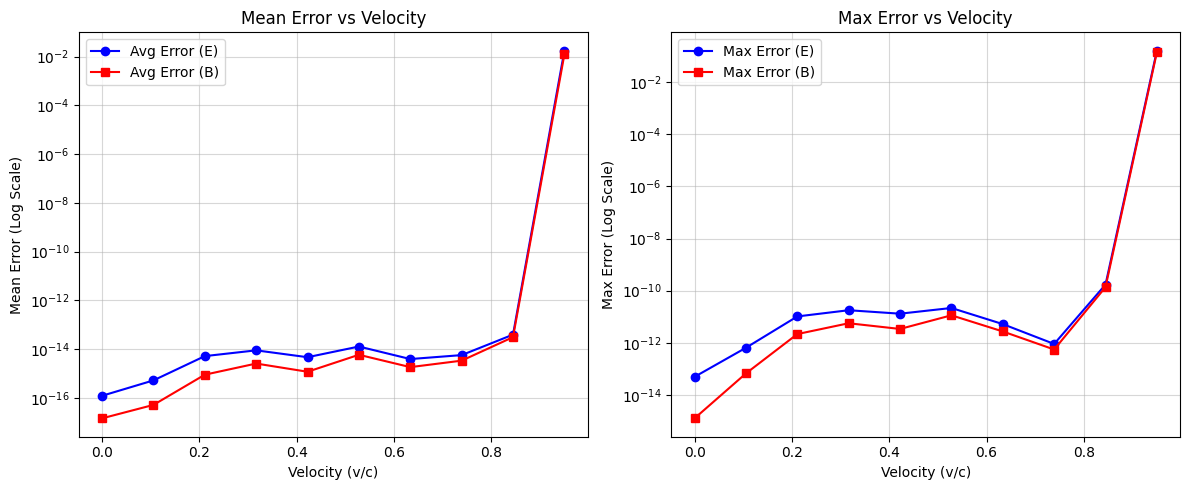

In [14]:
if __name__ == '__main__':
    #전하 1개인 경우
    verifier = CovarianceVerifier()
    verifier.add_charge(1.0,(0,0,0))
    
    N = 30
    x = np.linspace(-2, 2, N)
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij') #30
    
    # 0.0c부터 0.95c까지 10단계로 테스트
    v_list = np.linspace(0.0, 0.95, 10) 
    
    results = verifier.run_benchmark(X, Y, Z, v_list)
    verifier.plot_benchmark_results(results)

Starting Verification Benchmark (10 cases)...


  > v=0.00c : Avg Err E=1.80e-15, Max Err E=1.28e-12
  > v=0.11c : Avg Err E=2.70e-14, Max Err E=6.03e-11
  > v=0.21c : Avg Err E=2.65e-13, Max Err E=2.93e-10
  > v=0.32c : Avg Err E=3.98e-13, Max Err E=2.03e-09
  > v=0.42c : Avg Err E=8.68e-13, Max Err E=1.91e-08
  > v=0.53c : Avg Err E=1.55e-12, Max Err E=1.68e-08
  > v=0.63c : Avg Err E=2.99e-13, Max Err E=4.23e-10
  > v=0.74c : Avg Err E=6.97e-13, Max Err E=5.23e-09
  > v=0.84c : Avg Err E=1.74e-02, Max Err E=1.22e-01
  > v=0.95c : Avg Err E=1.55e-01, Max Err E=4.62e-01


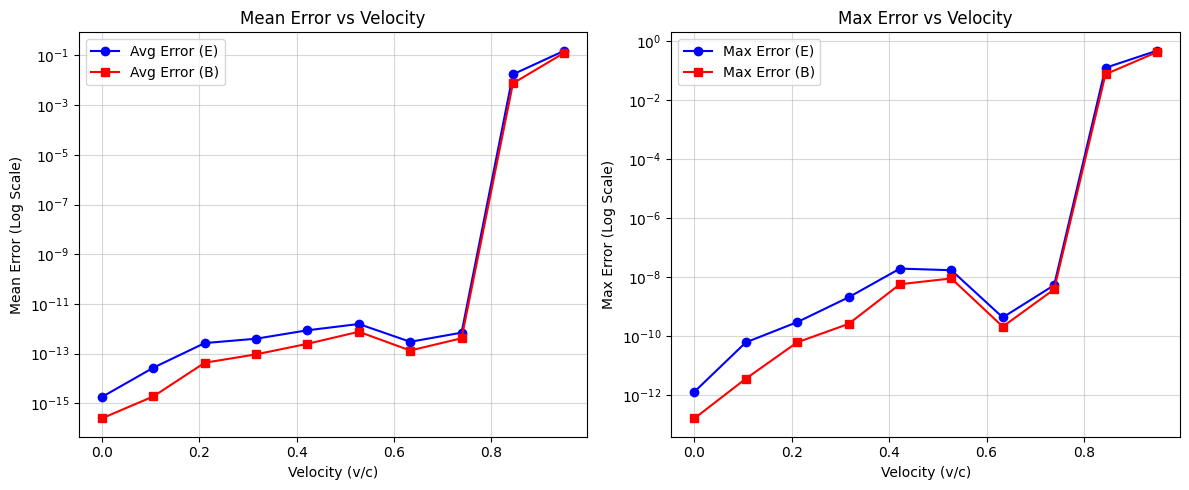

In [15]:
if __name__ == '__main__':
    #전하가 100개인 경우
    verifier = CovarianceVerifier()
    verifier.random_charges(100) 
    
    N = 30
    x = np.linspace(-2, 2, N)
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
    
    # 0.0c부터 0.95c까지 10단계로 테스트
    v_list = np.linspace(0.0, 0.95, 10) 
    
    results = verifier.run_benchmark(X, Y, Z, v_list)
    verifier.plot_benchmark_results(results)

In [10]:
class ParallelBenchmark:
    def __init__(self, engine_class=LWField):
        self.EngineClass = engine_class

    def run_core_scaling(self, grid_N=30, n_charges=100, max_cores=None):
        """
        [실험 1] 일정한 작업량에서 '코어 수'를 늘려가며 속도 측정
        """
        if max_cores is None:
            max_cores = cpu_count()
            
        # 테스트할 코어 수 리스트 (1, 2, 4, 8... Max)
        core_list = [1]
        c = 2
        while c <= max_cores:
            core_list.append(c)
            c *= 2
        if max_cores not in core_list:
            core_list.append(max_cores)
        core_list = sorted(list(set(core_list)))

        print(f"\nStarting Core Scaling Benchmark (Grid: {grid_N}^3, Charges: {n_charges})...")
        
        # 테스트 준비
        field = self.EngineClass()
        field.random_charges(n_charges)
        
        x = np.linspace(-2, 2, grid_N)
        X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
        velocity = [0.5, 0, 0]
        
        times = []
        
        for n_cores in core_list:
            print(f"  Testing with {n_cores} cores...", end="")
            start = time.perf_counter()
            

            if hasattr(field, 'calc_field_parallel'): #LWField의 병렬 함수명
                field.calc_field_parallel(X, Y, Z, velocity, num_cores=n_cores)
            elif hasattr(field, 'calc_static_field_parallel'): #TensorField의 병렬 함수명
                field.calc_static_field_parallel(X, Y, Z, num_cores=n_cores)
            
            end = time.perf_counter()
            elapsed = end - start
            times.append(elapsed)
            print(f" Done! ({elapsed:.4f}s)")
            
        return {'cores': core_list, 'times': times}

    def run_grid_scaling(self, grid_list, n_charges=100):
        """
        [실험 2] 최대 코어 상태에서 '격자 크기'를 늘려가며 한계 테스트
        """
        num_cores = cpu_count()
        print(f"\nStarting Grid Scaling Benchmark (Cores: {num_cores}, Charges: {n_charges})...")
        
        field = self.EngineClass()
        field.random_charges(n_charges, space_range=(-2.0, 2.0))
        velocity = [0.5, 0, 0]
        
        times = []
        
        for N in grid_list:
            print(f"  Testing Grid Size {N}x{N}x{N} ({N**3} points)...", end="")
            
            x = np.linspace(-2, 2, N)
            X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
            
            start = time.perf_counter()
            
            # 풀파워 병렬 실행
            if hasattr(field, 'get_transformed_field_parallel'):
                field.get_transformed_field_parallel(X, Y, Z, velocity, num_cores=num_cores)
            elif hasattr(field, 'calc_static_field_parallel'):
                field.calc_static_field_parallel(X, Y, Z, num_cores=num_cores)
                
            end = time.perf_counter()
            elapsed = end - start
            times.append(elapsed)
            print(f" Done! ({elapsed:.4f}s)")
            
        return {'grids': grid_list, 'times': times}

    def plot_results(self, core_data, grid_data):
        plt.figure(figsize=(14, 6))
        
        # 1. Core Scaling (Speedup)
        plt.subplot(1, 2, 1)
        cores = core_data['cores']
        times = core_data['times']
        # 스피드업 계산: T_1 / T_N
        speedup = [times[0] / t for t in times]
        
        plt.plot(cores, speedup, 'b-o', label='Actual Speedup', linewidth=2)
        plt.plot(cores, cores, 'k--', label='Ideal (Linear)', alpha=0.5) # 이상적인 선
        plt.xlabel('Number of Cores')
        plt.ylabel('Speedup Factor (x times)')
        plt.title('Performance vs Cores (Amdahl\'s Law)')
        plt.grid(True)
        plt.legend()
        plt.xticks(cores)
        
        # 2. Grid Scaling (Workload)
        plt.subplot(1, 2, 2)
        grids = grid_data['grids']
        g_times = grid_data['times']
        # 총 격자 점 개수 (N^3)
        points = [g**3 for g in grids]
        
        plt.plot(points, g_times, 'r-s', label='Calculation Time', linewidth=2)
        plt.xlabel('Total Grid Points (N^3)')
        plt.ylabel('Time (seconds)')
        plt.title(f'Scalability vs Grid Size (Max Cores)')
        plt.grid(True)
        plt.legend()
        
        plt.tight_layout()
        plt.show()


Starting Core Scaling Benchmark (Grid: 40^3, Charges: 100)...
  Testing with 1 cores... Done! (654.8202s)
  Testing with 2 cores... Done! (331.9765s)
  Testing with 4 cores... Done! (165.5322s)
  Testing with 8 cores... Done! (88.6189s)
  Testing with 16 cores... Done! (42.3584s)
  Testing with 32 cores... Done! (21.9619s)
  Testing with 64 cores... Done! (12.4764s)
  Testing with 128 cores... Done! (8.6207s)
  Testing with 256 cores... Done! (6.7779s)

Starting Grid Scaling Benchmark (Cores: 256, Charges: 100)...
  Testing Grid Size 20x20x20 (8000 points)... Done! (1.1994s)
  Testing Grid Size 30x30x30 (27000 points)... Done! (1.2589s)
  Testing Grid Size 40x40x40 (64000 points)... Done! (1.1891s)
  Testing Grid Size 50x50x50 (125000 points)... Done! (1.1794s)
  Testing Grid Size 60x60x60 (216000 points)... Done! (1.2972s)


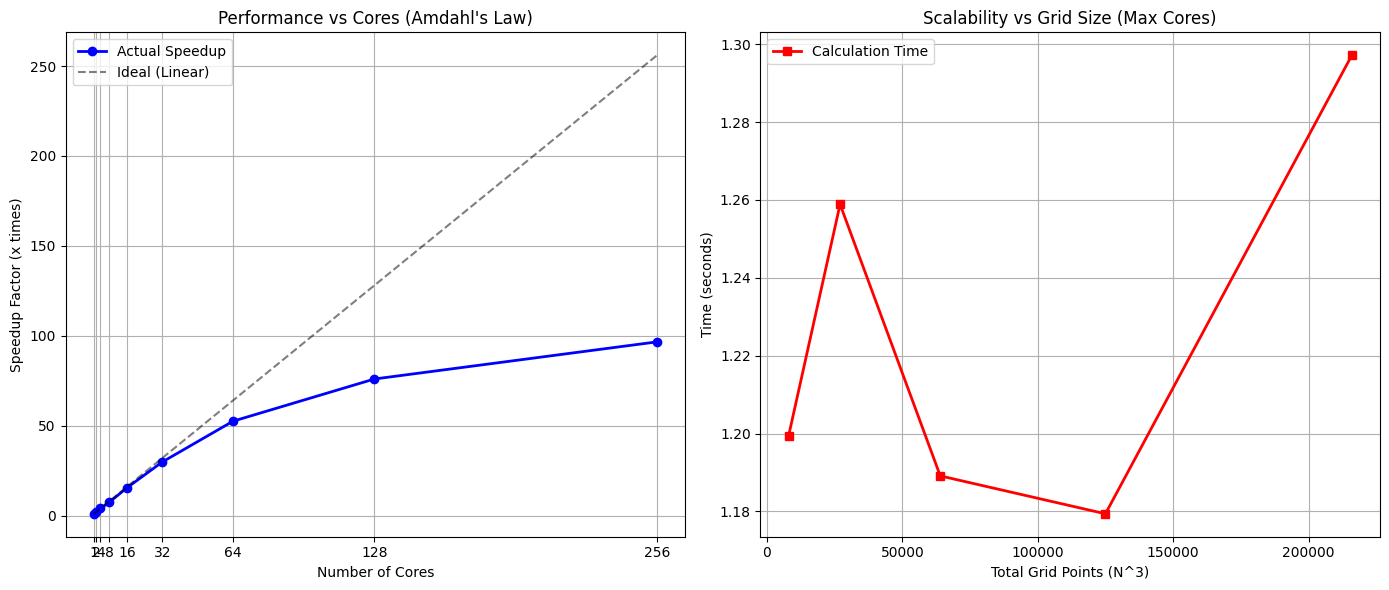

In [17]:
if __name__ == '__main__':
    # LWField
    bench = ParallelBenchmark(engine_class=LWField) 
    
    # [실험 1] 코어 수 늘리기 
    core_results = bench.run_core_scaling(grid_N=40, n_charges=100) #매우 오래걸리므로 돌릴 때 주의
    
    # [실험 2] 
    grid_list = [20, 30, 40, 50, 60] 
    grid_results = bench.run_grid_scaling(grid_list, n_charges=100)
    
    bench.plot_results(core_results, grid_results)


Starting Core Scaling Benchmark (Grid: 1^3, Charges: 1)...
  Testing with 1 cores... Done! (0.0216s)
  Testing with 2 cores... Done! (0.0290s)
  Testing with 4 cores... Done! (0.0344s)
  Testing with 8 cores... Done! (0.0596s)
  Testing with 16 cores... Done! (0.0984s)
  Testing with 32 cores... Done! (0.1719s)
  Testing with 64 cores... Done! (0.3273s)
  Testing with 128 cores... Done! (0.6354s)
  Testing with 256 cores... Done! (1.2779s)

Starting Grid Scaling Benchmark (Cores: 256, Charges: 10000)...
  Testing Grid Size 50x50x50 (125000 points)... Done! (7.1126s)
  Testing Grid Size 100x100x100 (1000000 points)... Done! (7.9370s)
  Testing Grid Size 150x150x150 (3375000 points)... Done! (10.1137s)
  Testing Grid Size 200x200x200 (8000000 points)... Done! (17.4108s)


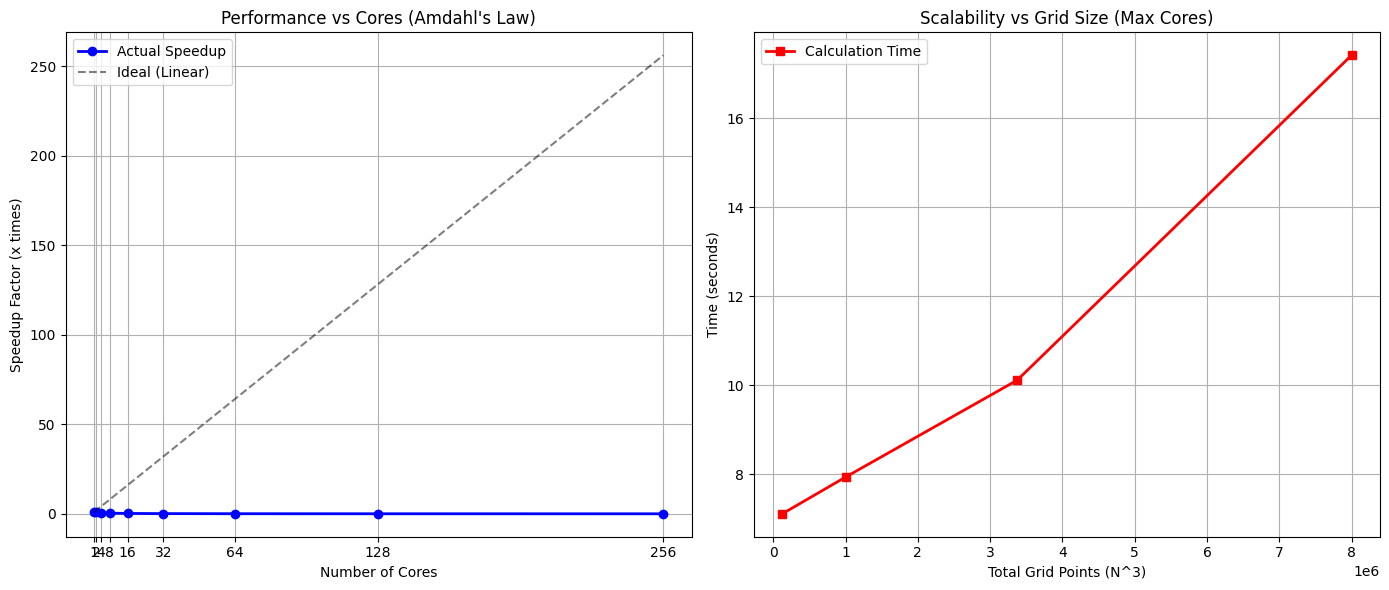

In [15]:
if __name__ == '__main__':
    # LWField
    bench = ParallelBenchmark(engine_class=LWField) 
    
    # [실험 1] 코어 수 늘리기 
    core_results = bench.run_core_scaling(grid_N=1, n_charges=1) #매우 오래걸리므로 돌릴 때 주의
    
    # [실험 2] 
    grid_list = [50,100,150,200] 
    grid_results = bench.run_grid_scaling(grid_list, n_charges=10000)
    
    bench.plot_results(core_results, grid_results)


Starting Core Scaling Benchmark (Grid: 100^3, Charges: 10000)...
  Testing with 1 cores...

 Done! (96.1422s)
  Testing with 2 cores... Done! (41.9554s)
  Testing with 4 cores... Done! (23.4114s)
  Testing with 8 cores... Done! (19.7470s)
  Testing with 16 cores... Done! (7.4782s)
  Testing with 32 cores... Done! (4.8093s)
  Testing with 64 cores... Done! (3.6789s)
  Testing with 128 cores... Done! (4.9463s)
  Testing with 256 cores... Done! (8.7936s)

Starting Grid Scaling Benchmark (Cores: 256, Charges: 10000)...
  Testing Grid Size 50x50x50 (125000 points)... Done! (8.6659s)
  Testing Grid Size 100x100x100 (1000000 points)... Done! (8.8873s)
  Testing Grid Size 150x150x150 (3375000 points)... Done! (11.2698s)
  Testing Grid Size 200x200x200 (8000000 points)... Done! (20.7746s)


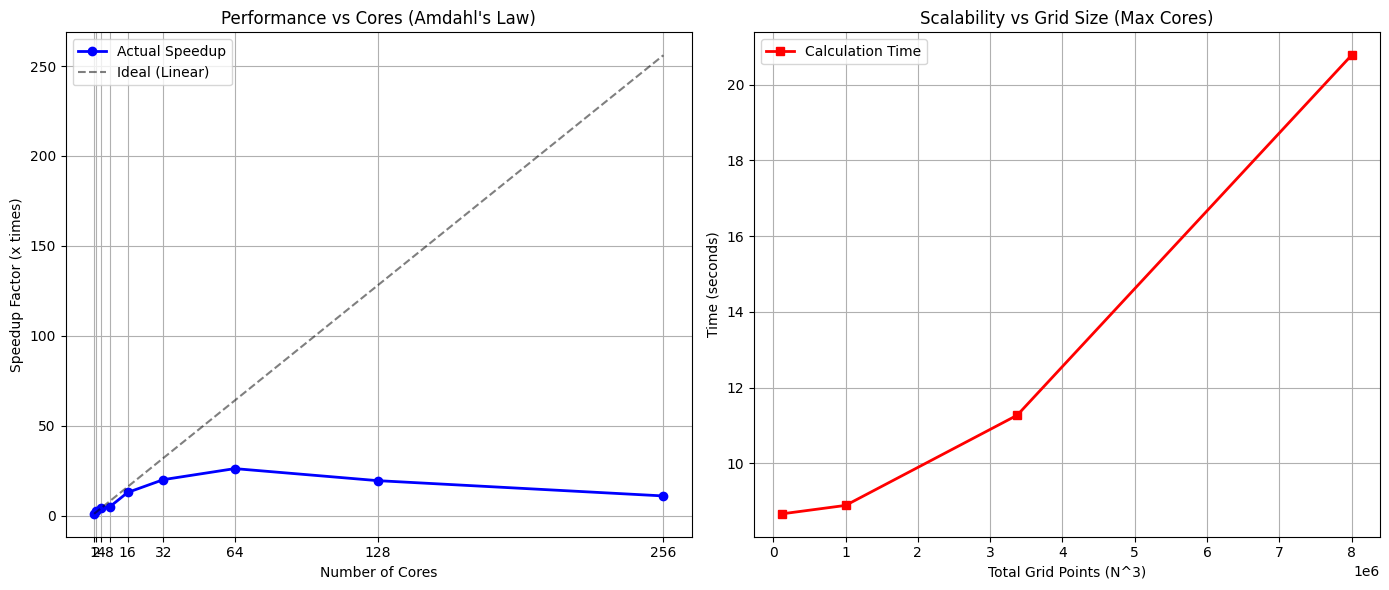

In [23]:
if __name__ == '__main__':
    # TensorField 
    bench = ParallelBenchmark(engine_class=TensorField) 
    
    # [실험 1] 코어 수 늘리기 (작업량 고정)
    core_results = bench.run_core_scaling(grid_N=100, n_charges=10000)
    
    # [실험 2] 격자 크기 늘리기 (풀파워)
    grid_list = [50,100,150,200] 
    grid_results = bench.run_grid_scaling(grid_list, n_charges=10000)

    bench.plot_results(core_results, grid_results)